# 07-Store 与长期记忆

Store · namespace · user_id · 跨 thread 记忆 · 第七课 · 约 40 分钟

### 目录

-   回顾：Checkpointer 解决了什么、解决不了什么
-   一、为什么需要 Store？（跨 thread 的长期记忆）
-   二、Store 的基本用法：namespace / put / search
-   三、把 Store 用进 LangGraph：compile(store=...) + 节点里读写
-   四、动手跑一下：同一个 user_id，不同 thread_id 也能“记得住”
-   五、常见坑速查
-   六、总结

### 回顾：图现在“可见”了，但记忆还分两种

上一课（`06_Streaming：让执行过程可见.ipynb`）我们把执行过程“直播”出来了：每一步跑了谁、state 怎么合并，你都能看见。

但当你开始做产品时，会立刻碰到另一个问题：**记忆其实分两种**。

在前面的课程里（尤其是 `04_Checkpointer与State管理.ipynb`，以及 `05_Human-in-the-Loop.ipynb` 里的 thread_id 配置），我们已经用 Checkpointer + thread_id 做到了：

- 同一个 thread_id：多次 invoke 能接着聊（短期记忆）
- 不同 thread_id：彼此隔离（不会串台）

这很像“聊天窗口的历史记录”。

但产品里你还经常要另一种记忆：**跨会话、跨 thread 的长期记忆**。

例如：

- 用户偏好（喜欢吃什么、不喜欢什么）
- 用户身份信息（职业、常用地址）
- 业务事实（已确认的工单编号、已授权的审批人）

这就轮到 Store 出场了。


### 一、为什么需要 Store？（跨 thread 的长期记忆）

如果只靠 Checkpointer：

- 用户换了新会话（新 thread_id）= 开了新存档
- 之前那句“我喜欢吃披萨”就不在这个新存档里了

> **类比：记事本 vs 通讯录**
>
> - Checkpointer 像“这次会话的记事本”：翻回去能看到刚刚聊过什么。
> - Store 像“通讯录/用户档案”：不管你开几个聊天窗口，同一个用户的档案都在。

所以：

- **短期记忆（会话内）**：Checkpointer（按 thread_id）
- **长期记忆（跨会话）**：Store（按 user_id / namespace）


In [1]:
import uuid

from langgraph.store.memory import InMemoryStore


store = InMemoryStore()

user_id = "u1"
namespace = (user_id, "memories")

memory_id = str(uuid.uuid4())
store.put(namespace, memory_id, {"food_preference": "我喜欢披萨"})

items = store.search(namespace, limit=10)
print("items_count:", len(items))
print("last_item:", items[-1].dict())

items_count: 1
last_item: {'namespace': ['u1', 'memories'], 'key': 'e4555229-e3bf-425b-97b7-3936b359c9dd', 'value': {'food_preference': '我喜欢披萨'}, 'created_at': '2026-08-06T14:35:22.848768+00:00', 'updated_at': '2026-08-06T14:35:22.848771+00:00', 'score': None}


### 二、Store 的基本用法：namespace / put / search

Store 里最容易忽略的点就一个：**namespace 是一个 tuple**。

你可以把它理解成“路径/目录”：

- `(user_id, "memories")`：这个用户的记忆
- `(user_id, "preferences")`：这个用户的偏好
- `(project_id, "kb")`：某个项目的知识

`put(namespace, key, value)` 写入，`search(namespace_prefix, ...)` 读取。

> **❓ 检查理解 ①**
>
> 为什么 `search` 的参数叫 `namespace_prefix`，而不是 `namespace`？
>
> -   A. 因为它按前缀匹配：传 `(user_id,)` 也能搜到 `(user_id,"memories")`
> -   B. 因为它只支持两级 namespace
> -   C. 因为它会把 namespace 自动 hash
>
> **✅ 答案：A**
>
> `search` 是按前缀匹配的：这让你可以一次性列出某个用户下的多个子空间（memories/preferences/...）。


In [2]:
# prefix 匹配示意：传 (user_id,) 会把这个用户下的所有 namespace 都搜出来
store.put((user_id, "preferences"), "p1", {"tone": "简洁"})
store.put((user_id, "preferences"), "p2", {"language": "中文"})

all_for_user = store.search((user_id,), limit=100)
print("all_for_user namespaces:", sorted({tuple(x.namespace) for x in all_for_user}))
print("all_for_user count:", len(all_for_user))

all_for_user namespaces: [('u1', 'memories'), ('u1', 'preferences')]
all_for_user count: 3


### 三、把 Store 用进 LangGraph：compile(store=...) + 节点里读写

关键点有三个：

1.  编译图时把 store 挂上：`builder.compile(checkpointer=..., store=store)`
2.  运行时用 `config["configurable"]["user_id"]` 指定“这个请求是谁”
3.  在节点函数里拿到 store，然后 `search/put`

我们不用真实大模型，写一个“固定规则的客服机器人”：

- 用户说「请记住：...」→ 把内容写进 store
- 用户问「我喜欢吃什么？」→ 从 store 里读出来回答

同一个 user_id 即使换 thread_id，也能读到同一份长期记忆。


In [3]:
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.store.base import BaseStore


def assistant_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = (user_id, "memories")

    last = state["messages"][-1]
    assert isinstance(last, HumanMessage)
    text = str(last.content)

    # 写入长期记忆
    if text.startswith("请记住："):
        memory = text.replace("请记住：", "", 1).strip()
        store.put(namespace, str(uuid.uuid4()), {"text": memory})
        return {"messages": [AIMessage(content=f"我记住了：{memory}")]}

    # 读取长期记忆
    if "我喜欢吃什么" in text:
        items = store.search(namespace, limit=10)
        if not items:
            return {"messages": [AIMessage(content="我还不知道你的口味偏好。你可以说：请记住：我喜欢...。")]}
        # InMemoryStore 默认按插入顺序返回，最后一个是最新写入
        latest = items[-1].value.get("text", "")
        return {"messages": [AIMessage(content=f"你之前说过：{latest}")]}

    return {"messages": [AIMessage(content="我能做两件事：1) 记住你的偏好；2) 回答你喜欢什么。")]} 


store_graph = InMemoryStore()
checkpointer = InMemorySaver()

builder = StateGraph(MessagesState)
builder.add_node("客服", assistant_node)
builder.add_edge(START, "客服")
builder.add_edge("客服", END)

graph_memory = builder.compile(checkpointer=checkpointer, store=store_graph)

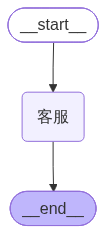

In [4]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod


display(
    Image(
        graph_memory.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

<div style="text-align:center; margin-top: 6px;">图：最小“客服 + 长期记忆”图（一个节点）</div>


### 四、动手跑一下：同一个 user_id，不同 thread_id 也能“记得住”

我们连续做三次调用：

1.  thread_id=t1, user_id=u1：让它“记住”偏好
2.  thread_id=t2, user_id=u1：换一个会话，问“我喜欢吃什么？”
3.  thread_id=t3, user_id=u2：换一个用户，再问一次

你应该看到：

- u1 在 t2 里仍然能读到 t1 写入的长期记忆
- u2 什么也读不到（隔离）


In [5]:
def run_once(text: str, *, thread_id: str, user_id: str):
    config = {"configurable": {"thread_id": thread_id, "user_id": user_id}}
    result = graph_memory.invoke({"messages": [HumanMessage(content=text)]}, config)
    reply = result["messages"][-1]
    print(f"[{thread_id=} {user_id=}] user: {text}")
    print("assistant:", reply.content)
    print()


run_once("请记住：我喜欢披萨", thread_id="t1", user_id="u1")
run_once("我喜欢吃什么？", thread_id="t2", user_id="u1")
run_once("我喜欢吃什么？", thread_id="t3", user_id="u2")

[thread_id='t1' user_id='u1'] user: 请记住：我喜欢披萨
assistant: 我记住了：我喜欢披萨

[thread_id='t2' user_id='u1'] user: 我喜欢吃什么？
assistant: 你之前说过：我喜欢披萨

[thread_id='t3' user_id='u2'] user: 我喜欢吃什么？
assistant: 我还不知道你的口味偏好。你可以说：请记住：我喜欢...。



> **关键观察：** 这里 thread_id 变了，但 user_id 没变。
>
> - Checkpointer 负责“同一 thread_id 的对话历史”
> - Store 负责“同一 user_id 的长期记忆”
>
> 所以你换会话不会丢用户档案。

> **❓ 检查理解 ②**
>
> 下面哪种组合，最符合“多用户 + 多会话”的产品直觉？
>
> -   A. thread_id 固定一个，user_id 每个用户一个
> -   B. user_id 固定一个，thread_id 每个会话一个
> -   C. user_id 每个用户一个，thread_id 每个会话一个
>
> **✅ 答案：C**
>
> user_id 决定“长期记忆属于谁”；thread_id 决定“这次会话的短期状态属于哪一段对话”。


### 五、常见坑速查

| 症状 | 原因 | 解法 |
| --- | --- | --- |
| 换 thread_id 之后记忆没了 | 你把“长期记忆”写进了 state（只会被 checkpointer 按 thread_id 存档） | 长期记忆写 store：`compile(store=...)` + `store.put/search` |
| 不同用户互相串台 | 你没有区分 user_id（namespace 乱了） | 把 `user_id` 放进 namespace，例如 `(user_id, "memories")` |
| search 结果顺序不稳定 | 不同 store backend 的默认排序不同 | 不要依赖默认顺序；需要顺序时按 `updated_at` 自己排序 |
| search 范围太大 | `namespace_prefix` 是前缀匹配 | 传更具体的 namespace（例如 `(user_id, "memories")`）或过滤 `item.namespace` |
| 以为 store 会自动“写回 state” | store 是外部 KV，不会自动出现在 state | 需要什么就从 store 读出来再写进 state（例如写进 `messages`） |


### 六、总结

| 概念 | 一句话解释 | 类比 |
| --- | --- | --- |
| Checkpointer | 保存“某个 thread 的完整 state 快照” | 这次会话的记事本 |
| Store | 保存“跨 thread 的长期信息（KV）” | 用户档案/通讯录 |
| namespace | Store 里的路径（tuple） | 文件夹路径 |
| user_id | 把长期记忆归属到“某个用户” | 用户唯一 ID |
| thread_id | 把短期状态归属到“某次会话/对话线程” | 会话窗口 ID |

> **一句话总结**
>
> **Checkpointer 管会话（thread_id），Store 管用户（user_id）。**
>
> 你要做“产品级记忆”，基本都会同时用两者。


📖 参考：

-   [LangGraph 官方文档 - Stores](https://docs.langchain.com/oss/python/langgraph/stores)
-   [LangGraph 官方文档 - Memory（add-memory）](https://docs.langchain.com/oss/python/langgraph/add-memory)
-   [LangGraph 官方文档 - Persistence](https://docs.langchain.com/oss/python/langgraph/persistence)
